# Trading Costs: Commission & Slippage

Realistic backtests must account for **trading costs**. quaver supports two cost models:

- **`CommissionConfig`** -- fixed per-trade fee + percentage of notional value
- **`SlippageConfig`** -- adverse fill price shift (buys fill higher, sells fill lower)

Both are applied on **every open and close event**, tracked per-trade in `TradeRecord`,
and reflected in the `net_pnl` (P&L after costs).

This notebook demonstrates how costs erode returns and how to configure them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from quaver.backtest.engine import BacktestEngine
from quaver.backtest.portfolio import CommissionConfig, Portfolio, SlippageConfig
from quaver.strategies.base import BaseStrategy, SignalOutput
from quaver.types import SignalDirection

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Setup: Synthetic Data & Simple Strategy

We create a simple oscillating price series and a strategy that buys at troughs and sells at peaks.
This gives us a controlled set of trades to study cost impact.

Generated 200 bars


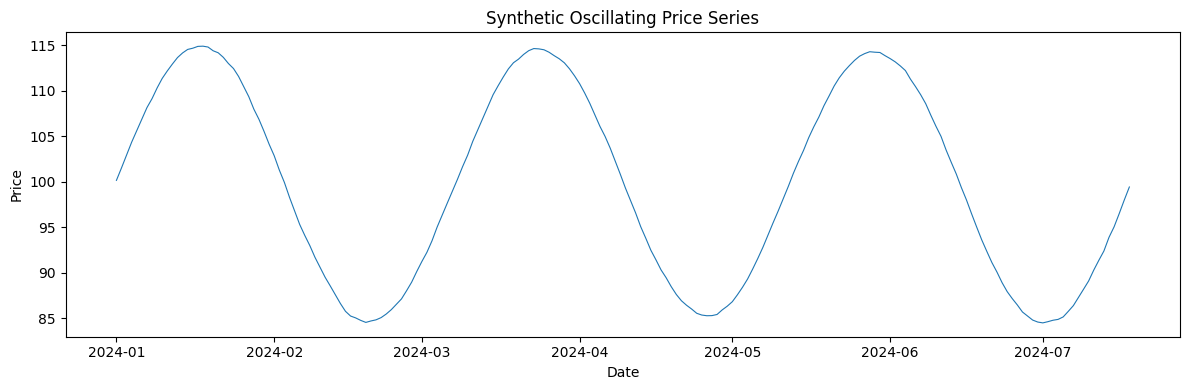

In [2]:
def make_candles(n=200):
    """Generate oscillating OHLCV data with predictable swings."""
    np.random.seed(7)
    base = 100 + 15 * np.sin(np.linspace(0, 6 * np.pi, n))
    noise = np.cumsum(np.random.randn(n) * 0.1)
    close = base + noise
    high = close + np.abs(np.random.randn(n) * 0.5)
    low = close - np.abs(np.random.randn(n) * 0.5)
    rows = []
    for i in range(n):
        rows.append(
            {
                "ts": datetime(2024, 1, 1) + timedelta(days=i),
                "open": close[i] + np.random.randn() * 0.2,
                "high": high[i],
                "low": low[i],
                "close": close[i],
                "volume": 1_000_000.0,
            }
        )
    return pd.DataFrame(rows)


class SwingTrader(BaseStrategy):
    """BUY when price crosses below SMA, SELL when above."""

    def validate_parameters(self):
        pass

    def get_required_candle_count(self):
        return 20

    def compute(self, candles, as_of):
        closes = candles["close"].values
        ma = np.mean(closes[-20:])
        price = closes[-1]
        if price < ma * 0.98:
            return SignalOutput(direction=SignalDirection.BUY, confidence=0.8)
        elif price > ma * 1.02:
            return SignalOutput(direction=SignalDirection.SELL, confidence=0.8)
        return None


candles = make_candles()
print(f"Generated {len(candles)} bars")

fig, ax = plt.subplots()
ax.plot(candles["ts"], candles["close"], linewidth=0.8)
ax.set_title("Synthetic Oscillating Price Series")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

## Run Backtest: No Costs vs. With Costs

We run the same strategy three times:
1. **No costs** (baseline)
2. **Commission only** (\$1 fixed + 0.1% per event)
3. **Commission + Slippage** (adds 0.1% adverse fill)

In [6]:
def run_with_costs(commission=None, slippage=None, label=""):
    strategy = SwingTrader(parameters={})
    portfolio = Portfolio(
        initial_capital=10_000,
        quantity_per_trade=10,
        commission=commission,
        slippage=slippage,
    )
    engine = BacktestEngine(
        strategy=strategy,
        portfolio=portfolio,
        instrument_id="SYN",
    )
    result = engine.run(candles)
    print(f"\n--- {label} ---")
    print(f"  Trades: {result.total_trades}")
    print(f"  Total Return: {result.total_return * 100:.2f}%")
    print(f"  Total Commission: ${result.total_commission:.2f}")
    print(f"  Total Slippage: ${result.total_slippage:.2f}")
    print(f"  Win Rate: {result.win_rate * 100:.1f}%")
    return result


r_none = run_with_costs(label="No Costs")

comm = CommissionConfig(fixed_per_trade=1.0, pct_of_notional=0.001)
r_comm = run_with_costs(commission=comm, label="Commission Only")

slip = SlippageConfig(slippage_pct=0.001)
r_both = run_with_costs(commission=comm, slippage=slip, label="Commission + Slippage")


--- No Costs ---
  Trades: 3
  Total Return: -5.57%
  Total Commission: $0.00
  Total Slippage: $0.00
  Win Rate: 0.0%

--- Commission Only ---
  Trades: 3
  Total Return: -5.69%
  Total Commission: $11.97
  Total Slippage: $0.00
  Win Rate: 0.0%

--- Commission + Slippage ---
  Trades: 3
  Total Return: -5.75%
  Total Commission: $11.98
  Total Slippage: $5.97
  Win Rate: 0.0%


## Compare Equity Curves

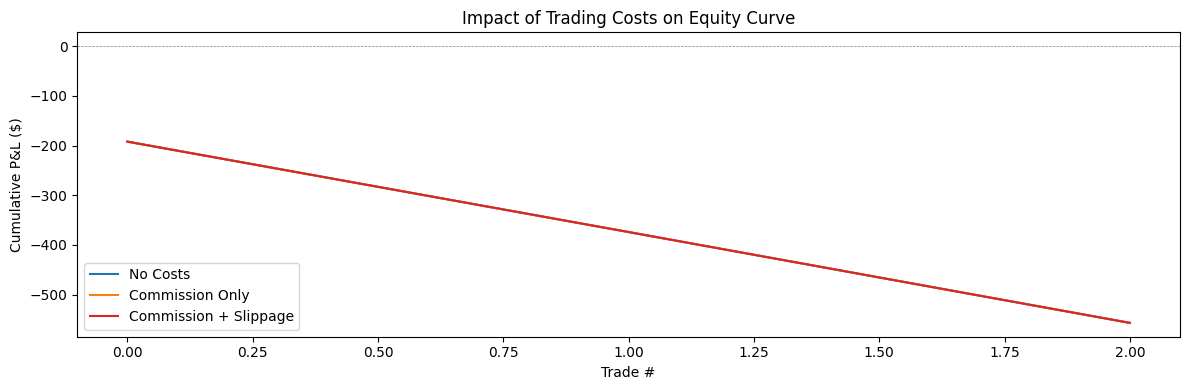

In [7]:
fig, ax = plt.subplots()
for result, label, color in [
    (r_none, "No Costs", "tab:blue"),
    (r_comm, "Commission Only", "tab:orange"),
    (r_both, "Commission + Slippage", "tab:red"),
]:
    cpnl = result.cumulative_pnl
    ax.plot(range(len(cpnl)), cpnl, label=label, linewidth=1.5, color=color)

ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("Trade #")
ax.set_ylabel("Cumulative P&L ($)")
ax.set_title("Impact of Trading Costs on Equity Curve")
ax.legend()
plt.tight_layout()
plt.show()

## Per-Trade Cost Breakdown

In [5]:
trades_df = pd.DataFrame(
    [
        {
            "entry": t.entry_ts.strftime("%Y-%m-%d"),
            "exit": t.exit_ts.strftime("%Y-%m-%d"),
            "entry_price": round(t.entry_price, 2),
            "exit_price": round(t.exit_price, 2),
            "pnl (ideal)": round(t.pnl, 2),
            "commission": round(t.commission, 2),
            "slippage": round(t.slippage_cost, 2),
            "net_pnl": round(t.net_pnl, 2),
        }
        for t in r_both.trades
    ]
)
trades_df

,entry,exit,entry_price,exit_price,pnl (ideal),commission,slippage,net_pnl
0,2024-01-27,2024-02-29,109.36,90.15,-192.10,4.00,2.00,-198.09
1,2024-04-03,2024-05-05,108.62,90.43,-181.92,3.99,1.99,-187.90
2,2024-06-08,2024-07-11,108.58,90.31,-182.78,3.99,1.99,-188.75


## How Costs Are Computed

### Commission
```python
CommissionConfig(fixed_per_trade=1.0, pct_of_notional=0.001)
# On each open and close:
#   fee = 1.0 + 0.001 * price * quantity
```

### Slippage
```python
SlippageConfig(slippage_pct=0.001)
# Buys fill at:  price * 1.001  (pay more)
# Sells fill at: price * 0.999  (receive less)
```

The `TradeRecord` separates:
- `pnl` -- ideal P&L using intended (pre-slippage) prices
- `commission` -- total commission (entry + exit)
- `slippage_cost` -- total dollar slippage (entry + exit)
- `net_pnl` = `pnl - commission - slippage_cost`